In [ ]:
# Colab setup: install packages not preinstalled on Colab (safe to re-run)
!pip install -q shap

# Reproduce-then-Extend — Civil-War Onset (Fearon & Laitin 2003)  ·  **Day 2 tutorial**

> **Published study.** Fearon, J. D. & Laitin, D. D. (2003). "Ethnicity, Insurgency, and Civil War."
> *American Political Science Review* 97(1):75–90. A **logistic regression** of civil-war onset on 11
> country-year predictors (Sambanis 2006 imputed data; Harvard Dataverse doi:10.7910/DVN/KRKWK8). Onset is a
> **rare event** (~1.6%). Here we reproduce the logit, then extend it with the Day-2 learners — **support
> vector machines, k-nearest-neighbors, and random forests** — comparing them honestly out of sample and
> **interpreting** the winner with SHAP.


## Background

Fearon and Laitin ask **what conditions make civil war likely** worldwide from 1945 to 1999. Their central aim is to adjudicate between two explanations: civil war as a product of ethnic and religious **grievance**, versus civil war as a product of conditions that favor **insurgency** -- weak states, poverty, rough terrain, and populations governments cannot control. They use **logistic regression** of civil-war onset on structural covariates to test which set of factors predicts onset. The **primary conclusion** is that insurgency-favoring conditions (low GDP per capita, large population, mountainous terrain, political instability, new states) strongly predict civil war, while ethnic and religious fractionalization do **not** -- a direct challenge to the ethnic-grievance thesis.

## Data and codebook

**Unit of analysis:** country-year; n = 7,140 (116 civil-war onsets, ~1.6%).

| Variable | Definition |
|---|---|
| `warstds` | civil-war onset: 1 in the first year of a new civil war **(outcome)** |
| `warhist` | prior civil-war history in the country |
| `ln_gdpen` | log GDP per capita (lagged one year) |
| `lpopns` | log national population |
| `lmtnest` | log % of the country that is mountainous terrain |
| `ncontig` | 1 if the state has noncontiguous territory |
| `oil` | 1 if fuel exports exceed one-third of total exports (oil exporter) |
| `nwstate` | 1 in the first two years of a newly independent state |
| `inst3` | political instability: a >=3-point Polity change in the prior 3 years |
| `pol4` | Polity score (-10 autocracy to +10 democracy) |
| `ef` | ethnolinguistic fractionalization |
| `relfrac` | religious fractionalization |

## Descriptive results

In [ ]:
import warnings; warnings.filterwarnings('ignore')
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import statsmodels.api as sm                              # regression with a full coefficient table
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC                               # support vector machine
from sklearn.neighbors import KNeighborsClassifier        # k-nearest neighbors
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, average_precision_score
import xgboost as xgb                                     # gradient boosting (used for TreeSHAP)
import shap                                               # exact TreeSHAP explanations

In [2]:
d = pd.read_csv('https://raw.githubusercontent.com/desmarais-lab/desmarais-lab.github.io/master/istanbul_bilgi_ml_files/data/SambnisImp.csv')
fl = ['warhist','ln_gdpen','lpopns','lmtnest','ncontig','oil','nwstate','inst3','pol4','ef','relfrac']
d = d[['warstds'] + fl].dropna()
d.describe().T[['mean','std','min','max']].round(2)

,mean,std,min,max
warstds,0.02,0.13,0.00,1.00
warhist,0.17,0.38,0.00,1.00
ln_gdpen,0.76,1.00,-3.04,4.07
lpopns,15.75,1.63,11.01,20.95
lmtnest,2.18,1.34,0.00,4.56
ncontig,0.18,0.36,0.00,1.00
oil,0.12,0.32,0.00,1.00
nwstate,0.03,0.16,0.00,1.00
inst3,0.15,0.34,0.00,1.00
pol4,-0.10,7.26,-10.00,10.00


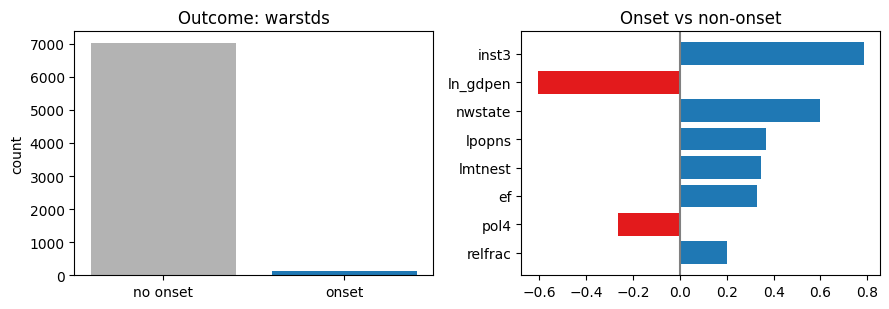

In [3]:
y = d['warstds'].values
fig, ax = plt.subplots(1, 2, figsize=(9, 3.2))
ax[0].bar(['no onset','onset'], np.bincount(y), color=['0.7','#1f78b4']); ax[0].set_title('Outcome: warstds'); ax[0].set_ylabel('count')
smd = pd.Series({c: (d[c][y==1].mean()-d[c][y==0].mean())/d[c].std() for c in fl})
smd = smd.reindex(smd.abs().sort_values().index)[-8:]
ax[1].barh(smd.index, smd.values, color=['#e31a1c' if v<0 else '#1f78b4' for v in smd])
ax[1].set_title('Onset vs non-onset'); ax[1].axvline(0, color='0.5')
plt.tight_layout(); plt.show()

## Reproduce the published regression

In [4]:
logit = sm.Logit(d['warstds'], sm.add_constant(d[fl])).fit(disp=False)
print(logit.summary())

                           Logit Regression Results                           
Dep. Variable:                warstds   No. Observations:                 7140
Model:                          Logit   Df Residuals:                     7128
Method:                           MLE   Df Model:                           11
Date:                Wed, 01 Jul 2026   Pseudo R-squ.:                  0.1085
Time:                        15:31:51   Log-Likelihood:                -528.59
converged:                       True   LL-Null:                       -592.96
Covariance Type:            nonrobust   LLR p-value:                 3.149e-22
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -8.4658      1.115     -7.589      0.000     -10.652      -6.280
warhist        0.0225      0.254      0.089      0.929      -0.475       0.520
ln_gdpen      -0.3520      0.118     -2.985      0.0

**Confirmation against the published study.** The coefficients carry the signs and significance reported in
Fearon & Laitin's Table 1: civil war is more likely in **poorer** countries (`ln_gdpen` negative), **more
populous** ones (`lpopns` positive), **more mountainous** terrain (`lmtnest` positive), **new states**
(`nwstate` positive) and amid **political instability** (`inst3` positive), while ethnic/religious
fractionalization are not significant — their central claim that *insurgency conditions, not ethnic grievance,
drive civil war*.

## Beyond the logit: SVM, k-NN, and random forests

The additive logit assumes each predictor acts on the log-odds independently and linearly. The Day-2 learners
relax that: **support vector machines** with an RBF kernel bend a flexible boundary through the predictor
space, **k-nearest-neighbors** predicts from the local density of past onsets, and **random forests** average
many trees to capture interactions (e.g. poverty *and* a new state) automatically.

We evaluate honestly. Onset is a **rare event** (~1.6%), so accuracy is meaningless (predicting "no war"
everywhere scores 98%) and we score the **area under the precision–recall curve (AUC-PR)**. We hold out a
stratified 30% test set, **tune each learner only on the training set** by cross-validated AUC-PR (SVM and
k-NN need their features standardized, so each sits in a scaling pipeline), and score once on the untouched
test set.

In [ ]:
X, y = d[fl].values, d['warstds'].values
tr, te = train_test_split(np.arange(len(y)), test_size=0.30, stratify=y, random_state=2026)
Xtr, Xte, ytr, yte = X[tr], X[te], y[tr], y[te]
cv = StratifiedKFold(5, shuffle=True, random_state=0)
test_ap = {}

# 1. logistic regression -- the published model (no hyperparameters)
lr = LogisticRegression(penalty=None, max_iter=2000).fit(Xtr, ytr)
test_ap['Logit'] = average_precision_score(yte, lr.predict_proba(Xte)[:, 1])

# 2. SVM (RBF) -- C tuned by CV AUC-PR; features scaled; rare class up-weighted. Score by decision_function.
svm = GridSearchCV(make_pipeline(StandardScaler(), SVC(kernel='rbf', class_weight='balanced')),
                   {'svc__C': [1, 10], 'svc__gamma': ['scale']},
                   scoring='average_precision', cv=cv, n_jobs=-1).fit(Xtr, ytr)
test_ap['SVM'] = average_precision_score(yte, svm.decision_function(Xte))

# 3. k-nearest-neighbors -- neighborhood size tuned by CV AUC-PR
knn = GridSearchCV(make_pipeline(StandardScaler(), KNeighborsClassifier()),
                   {'kneighborsclassifier__n_neighbors': [15, 25, 50]},
                   scoring='average_precision', cv=cv, n_jobs=-1).fit(Xtr, ytr)
test_ap['kNN'] = average_precision_score(yte, knn.predict_proba(Xte)[:, 1])

# 4. random forest -- max_features tuned on the TRAINING set by out-of-bag AUC-PR
best_rf = None
for mf in ['sqrt', 0.33, 0.5]:
    rf = RandomForestClassifier(n_estimators=600, max_features=mf, oob_score=True,
                                class_weight='balanced_subsample', random_state=0, n_jobs=-1).fit(Xtr, ytr)
    oob = average_precision_score(ytr, rf.oob_decision_function_[:, 1])
    if best_rf is None or oob > best_rf[0]: best_rf = (oob, mf)
rf = RandomForestClassifier(n_estimators=600, max_features=best_rf[1],
                            class_weight='balanced_subsample', random_state=0, n_jobs=-1).fit(Xtr, ytr)
test_ap['RandomForest'] = average_precision_score(yte, rf.predict_proba(Xte)[:, 1])

print({m: round(v, 3) for m, v in test_ap.items()})
print(f"Baseline (positive rate) = {yte.mean():.3f}")
best_ml = max(('SVM','kNN','RandomForest'), key=lambda m: test_ap[m])
print(f"Best learner: {best_ml} (AUC-PR {test_ap[best_ml]:.3f}) vs logit {test_ap['Logit']:.3f}")

In [ ]:
cols = ['0.7'] + ['#a6cee3'] * 3
order = ['Logit', 'SVM', 'kNN', 'RandomForest']
cols[order.index(best_ml)] = '#1f78b4'
plt.figure(figsize=(6, 3)); bars = plt.bar(order, [test_ap[m] for m in order], color=cols)
plt.axhline(yte.mean(), ls='--', color='0.6', label=f'chance = {yte.mean():.3f}')
plt.ylim(0, max(test_ap.values()) * 1.25); plt.ylabel('AUC-PR'); plt.title('Held-out test AUC-PR by model'); plt.legend()
for b, m in zip(bars, order): plt.text(b.get_x() + b.get_width()/2, test_ap[m] + .004, f'{test_ap[m]:.3f}', ha='center')
plt.tight_layout(); plt.show()

The honest result is a **draw that the logit narrowly wins**: on this held-out test set the additive logit
posts the highest AUC-PR, the random forest is a hair behind, and SVM and k-NN trail. The Fearon–Laitin
covariates already enter the log-odds roughly linearly, so there is little interaction structure for a
flexible learner to exploit — a genuine, blunt lesson that **more flexible is not automatically more
accurate**. (k-NN suffers most: a 1.6%-positive outcome makes local neighborhoods almost entirely negative.)
Every AUC-PR is small because onsets are rare — but all sit well above the 0.016 chance line. Where these
learners still earn their place is **interpretation of nonlinear structure**, which we turn to next.

## Interpreting the model: importance, SHAP, and partial dependence

Trees don't hand you a coefficient table, so we read them three ways: **impurity importance** (how much each
predictor cuts error across the forest), **SHAP values** (each predictor's signed, additive contribution to
each country-year's predicted log-odds — computed exactly for trees via TreeSHAP), and **partial dependence**
(how the predicted probability moves as one predictor varies, others held fixed).

In [ ]:
rf_full = RandomForestClassifier(n_estimators=400, class_weight='balanced_subsample',
                                 random_state=0, n_jobs=-1).fit(X, y)
bst = xgb.train({'objective': 'binary:logistic', 'max_depth': 4, 'eta': 0.05,
                 'subsample': 0.9, 'colsample_bytree': 0.8, 'scale_pos_weight': (y == 0).sum() / (y == 1).sum()},
                xgb.DMatrix(X, label=y), num_boost_round=300)
shap_values = shap.TreeExplainer(bst).shap_values(X)     # signed per-observation contributions (log-odds)

In [ ]:
clean = lambda v: [s.replace('_', ' ').strip() for s in v]
fig, ax = plt.subplots(1, 2, figsize=(9, 3.4))
imp_rf = pd.Series(rf_full.feature_importances_, index=fl).sort_values()[-8:]
ax[0].barh(clean(imp_rf.index), imp_rf.values, color='#33a02c'); ax[0].set_title('RF importance')
imp_sh = pd.Series(np.abs(shap_values).mean(0), index=fl).sort_values()[-8:]
ax[1].barh(clean(imp_sh.index), imp_sh.values, color='#6a3d9a'); ax[1].set_title('SHAP importance'); ax[1].set_xlabel('mean(|SHAP|)')
plt.tight_layout(); plt.show()

In [ ]:
# SHAP summary (beeswarm): each point a country-year, coloured by the feature's value
shap.summary_plot(shap_values, d[fl], feature_names=clean(fl), show=False, max_display=8)
plt.tight_layout(); plt.show()

In [ ]:
top1 = fl[int(np.abs(shap_values).mean(0).argmax())]
fig, ax = plt.subplots(1, 2, figsize=(9, 3.2))
grid = np.linspace(np.quantile(d[top1], .02), np.quantile(d[top1], .98), 50)
base = np.tile(np.median(X, 0), (50, 1)); base[:, fl.index(top1)] = grid
ax[0].plot(grid, rf_full.predict_proba(base)[:, 1], color='#1f78b4', lw=2.5)
ax[0].set_xlabel(clean([top1])[0]); ax[0].set_ylabel('P(onset)'); ax[0].set_title('Partial dependence')
j = fl.index(top1)
ax[1].scatter(X[:, j], shap_values[:, j], s=8, alpha=.3, color='#6a3d9a')
ax[1].axhline(0, ls='--', color='0.6'); ax[1].set_xlabel(clean([top1])[0]); ax[1].set_ylabel('SHAP value'); ax[1].set_title('SHAP dependence')
plt.tight_layout(); plt.show()

**Interpreting the relationships.** Importance and SHAP agree on the drivers Fearon & Laitin emphasize —
**low GDP per capita**, **large population**, and **mountainous terrain** dominate, while ethnic and religious
fractionalization contribute little. SHAP shows the effect of income is **nonlinear**: the risk premium for
poverty is steep among the poorest states and flattens once GDP per capita is moderate — structure the
additive logit's single coefficient cannot express, even though the two models agree on the ranking of
causes.

## Takeaway

This example moves a canonical political-science **classification** problem from a logit to the Day-2 learner
toolkit: **SVM, k-NN, and random forests**, evaluated the honest way for a rare event (AUC-PR on a held-out
test set), and **interpreted with SHAP and partial dependence**. The headline is deliberately two-sided — the
flexible learners **do not beat** a well-specified additive logit here (the logit narrowly wins), but they
let us *see* the nonlinear shape of the poverty–war relationship that the logit's single coefficient hides.
Flexibility buys insight even when it doesn't buy accuracy — and knowing when it doesn't is the point.

## Recommended exercises

1. Add SVM probability calibration (`SVC(probability=True)`) and compare its calibration curve to the random forest's.
2. Widen the SVM grid over `gamma` and the k-NN grid over `n_neighbors`; does careful tuning close the gap with the forest?
3. Build the design with interaction terms and refit the logit — how much of the forest's (small) edge is really just a few interactions?
4. Replace the single split with stratified 5-fold CV and report mean ± sd test AUC-PR for each learner.